In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Load the dataset

import pandas as pd

df = pd.read_csv("data/Housing.csv")

# Display first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
import os

print(os.getcwd())


C:\Users\varsha\Desktop\House-Price-Prediction


In [4]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'data', 'House_Price_Prediction.ipynb.ipynb', 'images', 'model', 'notebook', 'requirements.txt', 'venv']


In [5]:
print(os.listdir(".."))

['1st review [Autosaved].pptx', '360 Extreme Browser.lnk', '4 sem.jpg', 'axdhar.jpg', 'BINDING.pdf', 'Call', 'code-whisper-guide-main', 'DCIM', 'Desktop - Shortcut.lnk', 'desktop.ini', 'Doc1.pdf', 'Document1 (3).pdf', 'Documents', 'Download', 'f6ac88ba-e818-4b8e-946c-163f40763043.jpg', 'Front-sheet Project Phase-1 updated 1.docx', 'full stack', 'Gallery', 'House-Price-Prediction', 'IBM.pdf', 'memory card', 'Movies', 'my ppt.pptx', 'nlp ass 2.pdf', 'nlp ass 23.pdf', 'NSS report.docx', 'NSS report.pdf', 'OS (C) - Shortcut (2).lnk', 'photo.jpg', 'PhotoCollage', 'photoresizer', 'Pictures', 'Pictures - Shortcut (2).lnk', 'Pictures - Shortcut.lnk', 'poshan-Image', 'ppt template (2).pdf', 'ppt template.pdf', 'PPT1.pdf', 'pro re 0.pdf', 'pro re 0.pptx', 'Project Title.pdf', 'reactjs', 'REVIEW 2 PPT (4).pptx', 's harsha folder', 'SAMPLE final_report PHASE 1.pdf', 'SAMPLE final_report soft copy updated phase-1 (1).pdf', 'SAMPLE final_report soft copy updated phase-1.docx', 'SAMPLE final_report s

In [7]:
# Check the number of rows and columns

print("Shape of Dataset:", df.shape)

Shape of Dataset: (545, 13)


In [8]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [9]:
df.tail(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
535,2100000,3360,2,1,1,yes,no,no,no,no,1,no,unfurnished
536,1960000,3420,5,1,2,no,no,no,no,no,0,no,unfurnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [11]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [12]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [15]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [16]:
# Numerical Columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical Columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='str')

Categorical Columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [17]:
for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())


mainroad
<StringArray>
['yes', 'no']
Length: 2, dtype: str

guestroom
<StringArray>
['no', 'yes']
Length: 2, dtype: str

basement
<StringArray>
['no', 'yes']
Length: 2, dtype: str

hotwaterheating
<StringArray>
['no', 'yes']
Length: 2, dtype: str

airconditioning
<StringArray>
['yes', 'no']
Length: 2, dtype: str

prefarea
<StringArray>
['yes', 'no']
Length: 2, dtype: str

furnishingstatus
<StringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str


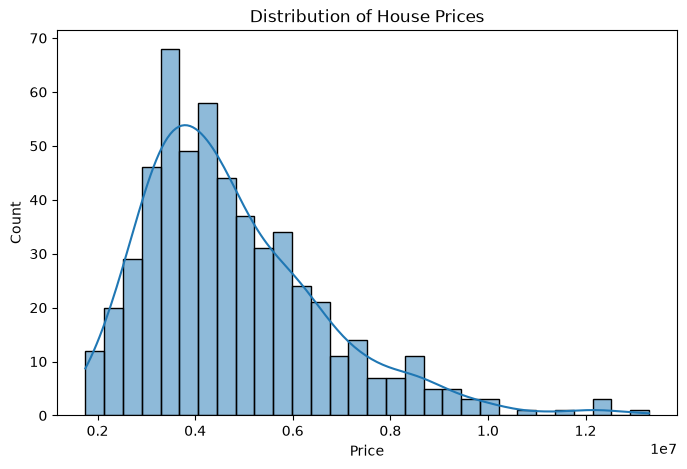

In [54]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.savefig("images/distribution.png", dpi=300, bbox_inches="tight")

plt.show()

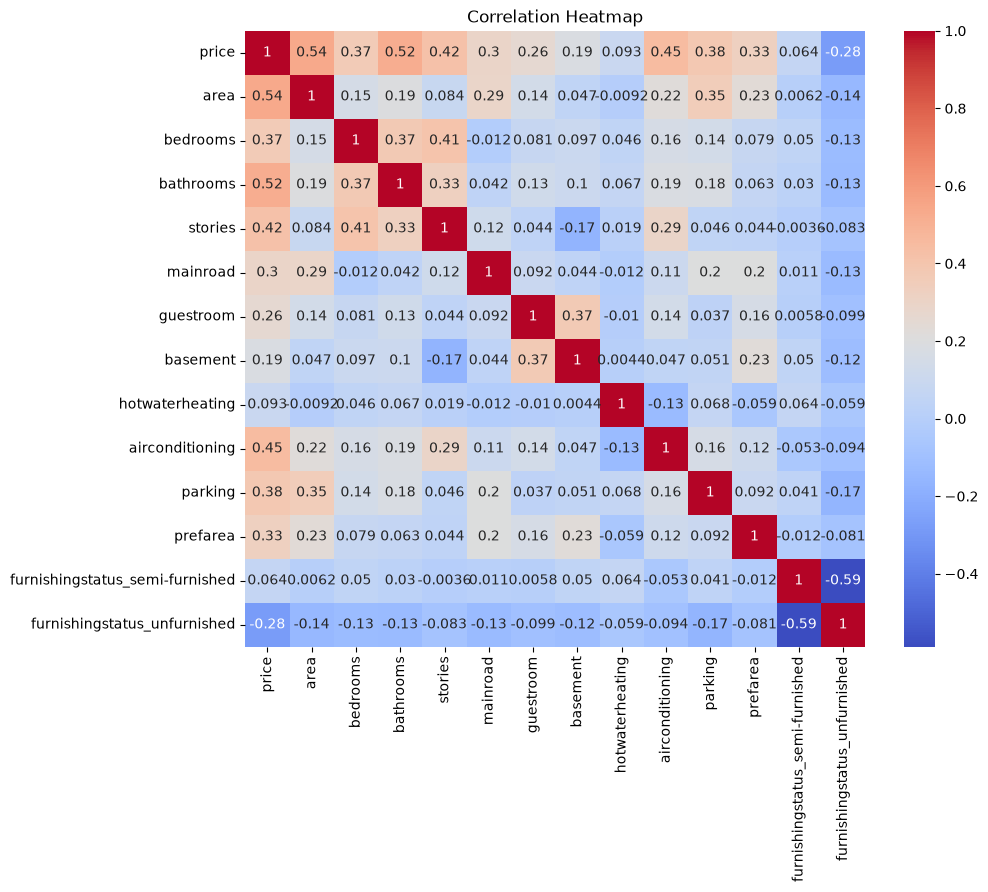

In [55]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

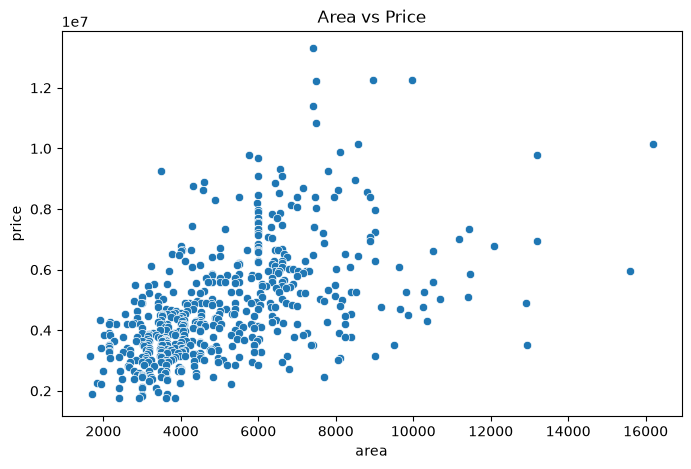

In [56]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='area',
                y='price',
                data=df)

plt.title("Area vs Price")

plt.savefig("images/area_vs_price.png", dpi=300, bbox_inches="tight")

plt.show()

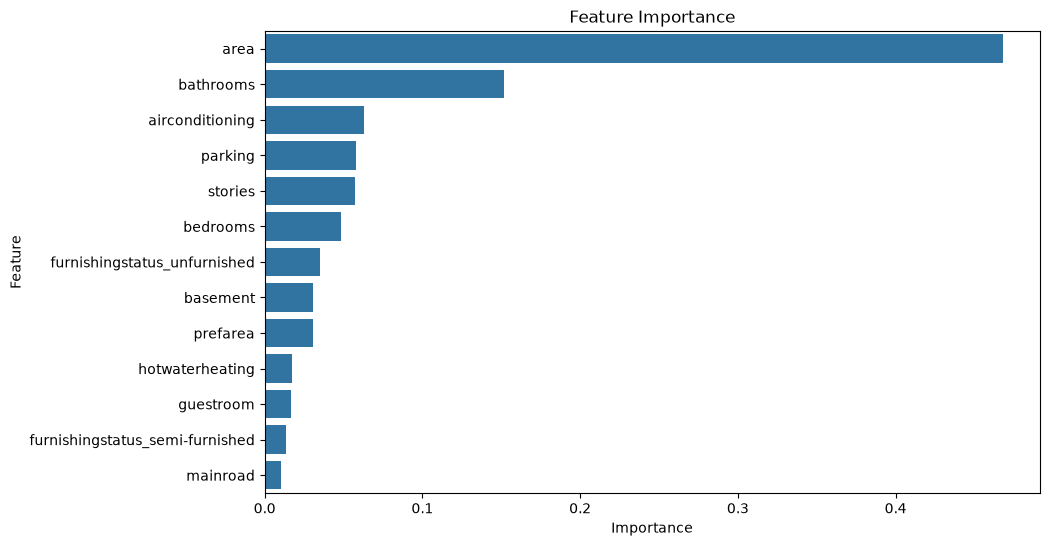

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

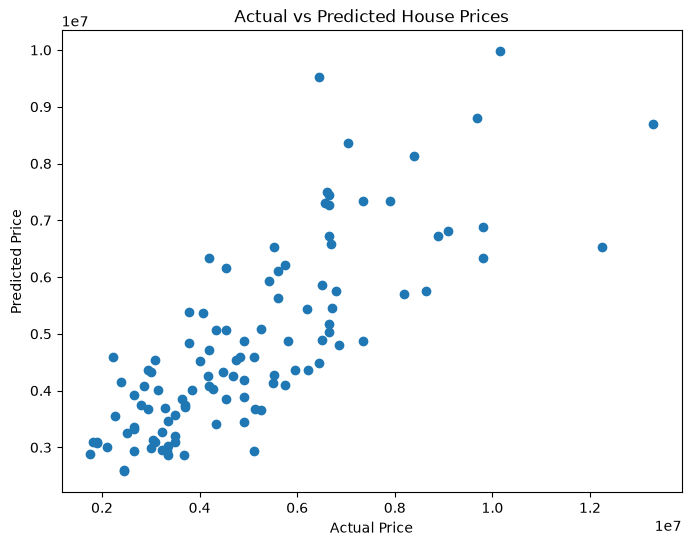

In [58]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")

plt.show()

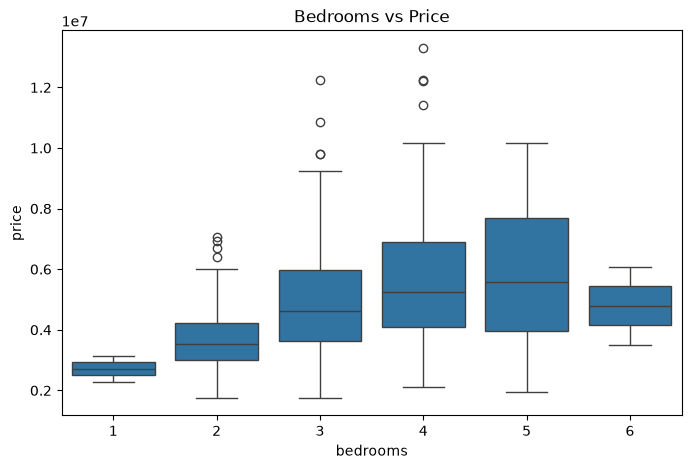

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x='bedrooms',
            y='price',
            data=df)

plt.title("Bedrooms vs Price")

plt.show()

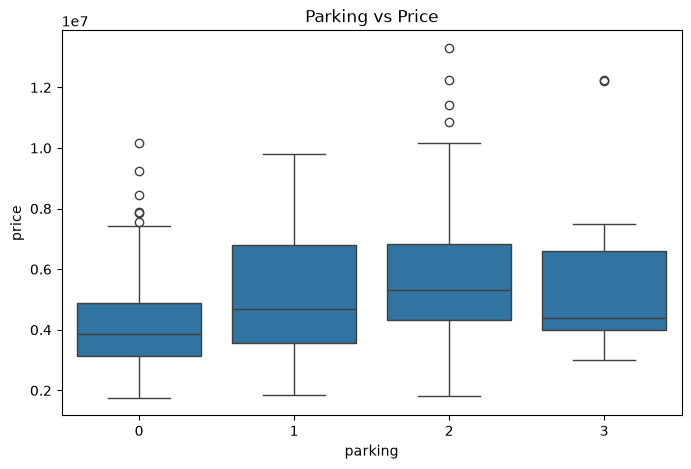

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x='parking',
            y='price',
            data=df)

plt.title("Parking vs Price")

plt.show()

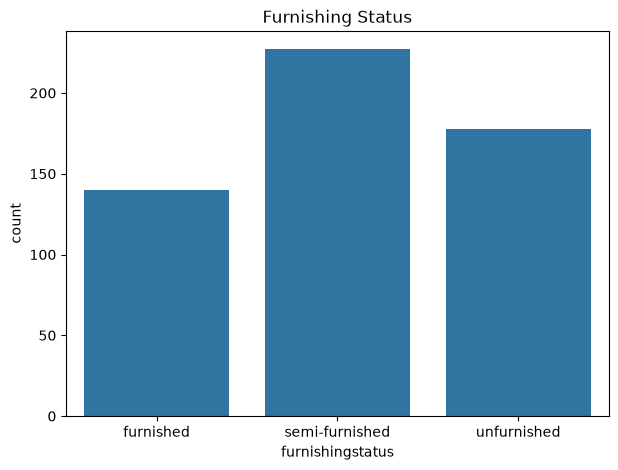

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(x='furnishingstatus',
              data=df)

plt.title("Furnishing Status")

plt.show()

In [25]:
categorical_columns = df.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [26]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col] = df[col].map({'yes':1, 'no':0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [27]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [28]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    bool 
 13  f

In [31]:
# Features (Independent Variables)
X = df.drop('price', axis=1)

# Target (Dependent Variable)
y = df['price']

In [32]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [35]:
# Create Linear Regression Model

lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [36]:
lr_predictions = lr.predict(X_test)

lr_predictions[:10]

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.3272256 , 3294646.25725955, 3532275.09556559,
       5611774.56836476, 6368145.98732718, 2722856.95689985,
       2629405.61585782])

In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

print("Linear Regression Results")
print("---------------------------")

print("MAE :", mean_absolute_error(y_test, lr_predictions))

print("MSE :", mean_squared_error(y_test, lr_predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_predictions)))

print("R² Score :", r2_score(y_test, lr_predictions))

Linear Regression Results
---------------------------
MAE : 970043.4039201641
MSE : 1754318687330.664
RMSE : 1324506.9600914388
R² Score : 0.6529242642153184


In [38]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")

Decision Tree Model Trained Successfully!


In [39]:
dt_predictions = dt.predict(X_test)

In [40]:
print("Decision Tree Results")
print("---------------------------")

print("MAE :", mean_absolute_error(y_test, dt_predictions))

print("MSE :", mean_squared_error(y_test, dt_predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_predictions)))

print("R² Score :", r2_score(y_test, dt_predictions))

Decision Tree Results
---------------------------
MAE : 1195266.0550458715
MSE : 2642802637614.6787
RMSE : 1625669.904259373
R² Score : 0.4771459275854347


In [41]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [42]:
rf_predictions = rf.predict(X_test)

In [43]:
print("Random Forest Results")
print("---------------------------")

print("MAE :", mean_absolute_error(y_test, rf_predictions))

print("MSE :", mean_squared_error(y_test, rf_predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_predictions)))

print("R² Score :", r2_score(y_test, rf_predictions))

Random Forest Results
---------------------------
MAE : 1022560.0527522935
MSE : 1964193399645.3335
RMSE : 1401496.8425384816
R² Score : 0.6114024924156645


In [44]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, dt_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE
0,Linear Regression,0.652924,9.700434e+05
2,Random Forest,0.611402,1.022560e+06
1,Decision Tree,0.477146,1.195266e+06


In [45]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': rf_predictions
})

comparison.head(10)

,Actual Price,Predicted Price
316,4060000,5368580.00
77,6650000,7270270.00
360,3710000,3751028.75
90,6440000,4493790.00
493,2800000,3751650.00
209,4900000,3440360.00
176,5250000,5092920.00
249,4543000,5063730.00
516,2450000,2575090.00
426,3353000,2873276.00


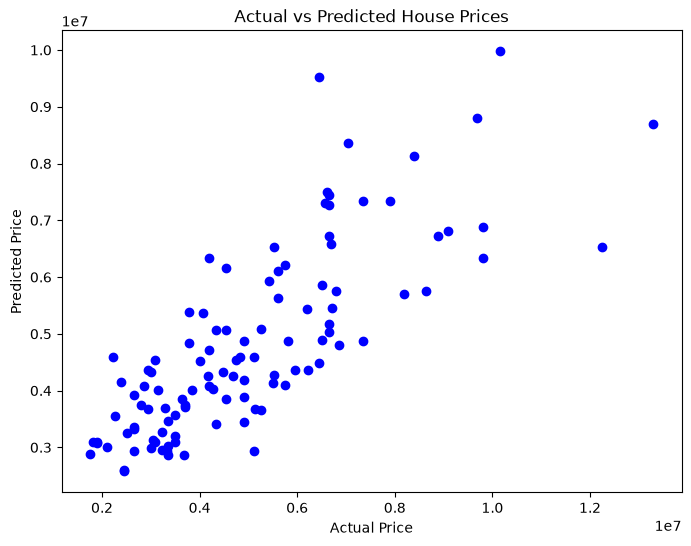

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions, color='blue')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

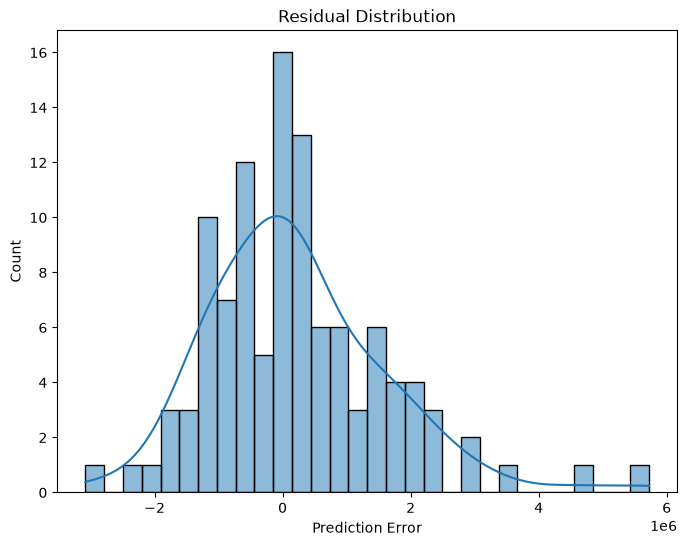

In [47]:
residuals = y_test - rf_predictions

plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [48]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
0,area,0.467917
2,bathrooms,0.151526
8,airconditioning,0.062718
9,parking,0.057820
3,stories,0.057137
1,bedrooms,0.048608
12,furnishingstatus_unfurnished,0.034998
6,basement,0.030804
10,prefarea,0.030519
7,hotwaterheating,0.017255


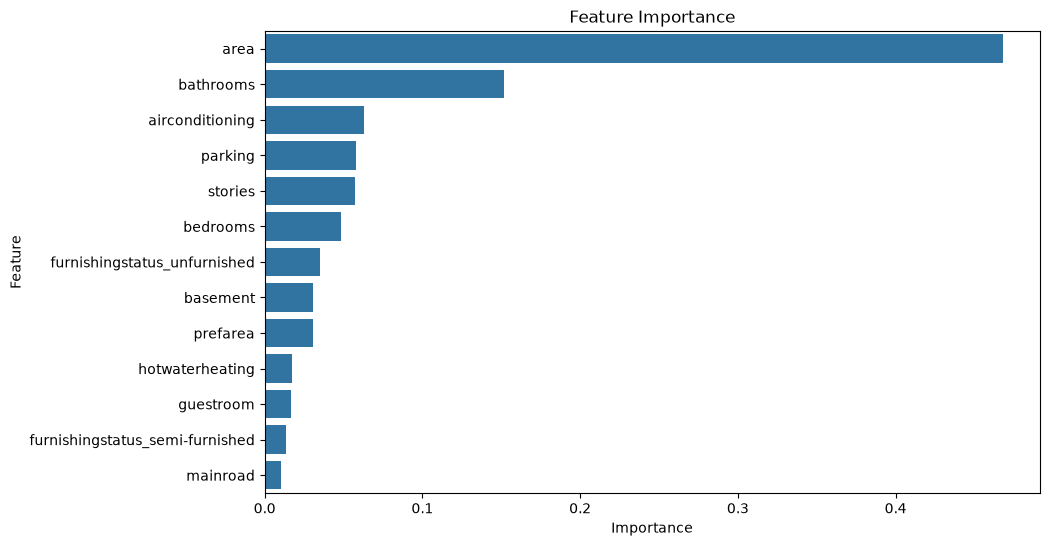

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [50]:
import joblib

joblib.dump(rf, "model/house_price_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [51]:
loaded_model = joblib.load("model/house_price_model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [52]:
sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted Price:", prediction[0])
print("Actual Price:", y.iloc[0])

Predicted Price: 8698907.0
Actual Price: 13300000


In [53]:
print("="*60)
print("🏠 HOUSE PRICE PREDICTION PROJECT COMPLETED")
print("="*60)

print("\nDataset Shape :", df.shape)
print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

print("\nBest Model : Random Forest Regressor")

print("\nR² Score :", round(r2_score(y_test, rf_predictions),3))

print("\nModel Saved Successfully!")

print("\nProject Completed Successfully!")

🏠 HOUSE PRICE PREDICTION PROJECT COMPLETED

Dataset Shape : (545, 14)
Training Samples : 436
Testing Samples : 109

Best Model : Random Forest Regressor

R² Score : 0.611

Model Saved Successfully!

Project Completed Successfully!
